In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("cleaned_taxi_data.csv")

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

hourly_df = df.set_index("tpep_pickup_datetime").resample("H").agg({
    "trip_distance":"count",
    "total_amount":"mean"
})

hourly_df.rename(columns={
    "trip_distance":"trips",
    "total_amount":"avg_fare"
}, inplace=True)

hourly_df = hourly_df.dropna()

/var/folders/0d/8z298r691kbfwbztnkk4zq840000gn/T/ipykernel_9811/3535068304.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_taxi_data.csv")


In [4]:
train = hourly_df[:-168]
test = hourly_df[-168:]

In [5]:
model = SARIMAX(
    train["trips"],
    order=(2,1,2),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.93941D+00    |proj g|=  5.59865D-01


 This problem is unconstrained.



At iterate    5    f=  7.65579D+00    |proj g|=  1.61587D-01

At iterate   10    f=  7.63666D+00    |proj g|=  2.22625D-02

At iterate   15    f=  7.63558D+00    |proj g|=  1.00350D-02

At iterate   20    f=  7.63267D+00    |proj g|=  4.25392D-02

At iterate   25    f=  7.63224D+00    |proj g|=  3.30076D-03

At iterate   30    f=  7.63224D+00    |proj g|=  5.14943D-04

At iterate   35    f=  7.63223D+00    |proj g|=  1.23676D-02

At iterate   40    f=  7.63193D+00    |proj g|=  3.76254D-02

At iterate   45    f=  7.61075D+00    |proj g|=  1.78094D-01

At iterate   50    f=  7.58320D+00    |proj g|=  2.51849D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                trips   No. Observations:                 2020
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -15318.058
Date:                              Thu, 12 Mar 2026   AIC                          30650.116
Time:                                      11:00:42   BIC                          30689.209
Sample:                                           0   HQIC                         30664.482
                                             - 2020                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2641      0.044     29.003      0.000       1.179       1.349
ar.L2         -0.42

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


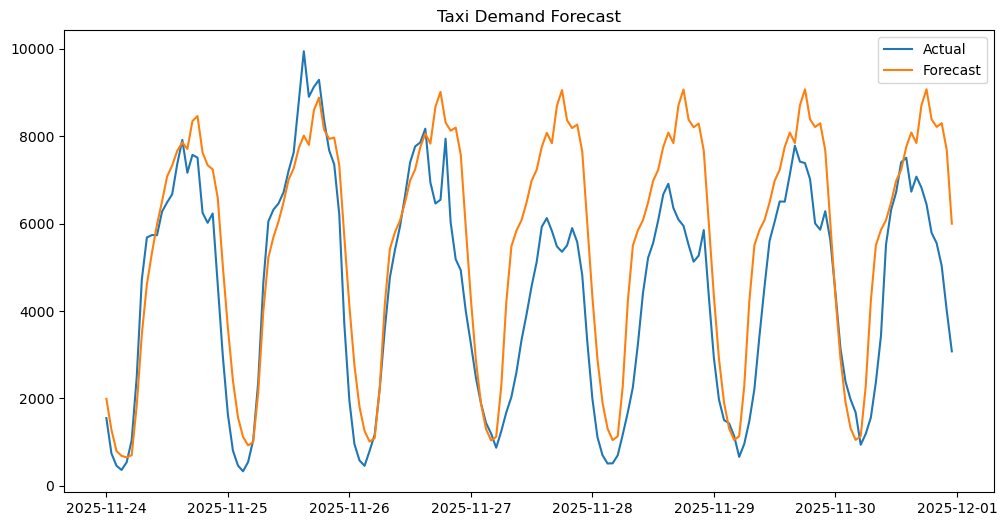

In [12]:
forecast = results.get_forecast(steps=len(test))
forecast_demand = forecast.predicted_mean

forecast_demand.index = test.index

plt.figure(figsize=(12,6))

plt.plot(test.index, test["trips"], label="Actual")
plt.plot(forecast_demand.index, forecast_demand, label="Forecast")

plt.legend()

plt.title("Taxi Demand Forecast")

plt.savefig("demand_forecast.png")

plt.show()